## Results
In this notebook the results are analysed.

In [1]:
import matplotlib.pyplot as plt

import pandas as pd
from pathlib import Path

from reacton.ipywidgets import color

#Creating the path to the correct folder and then we append the scenario file name to store the results, first we check for scenario 0
base_path = Path.cwd() / "results"
results0 = pd.read_csv(base_path / "S0.csv")
results0.head()

,truck_id,generated_at_step,removed_at_step,travel_time_min,travel_distance_m,sink_id,scenario,replication
0,Truck6,0,3,3,1930.000000,1710,S0,0
1,Truck12,0,4,4,3185.017867,1710,S0,0
2,Truck15,0,4,4,2990.000000,3736,S0,0
3,Truck16,0,6,6,4778.025000,3237,S0,0
4,Truck33,5,9,4,2990.000000,3736,S0,0


In [2]:
#replicated for all scenarios
results1 = pd.read_csv(base_path / "S1.csv")
results2 = pd.read_csv(base_path / "S2.csv")
results3 = pd.read_csv(base_path / "S3.csv")
results4 = pd.read_csv(base_path / "S4.csv")
print(results4.columns)

bridges0 = pd.read_csv(base_path/"bridges_S0.csv")
bridges1 = pd.read_csv(base_path/"bridges_S1.csv")
bridges2 = pd.read_csv(base_path/"bridges_S2.csv")
bridges3 = pd.read_csv(base_path/"bridges_S3.csv")
bridges4 = pd.read_csv(base_path/"bridges_S4.csv")
bridges0.columns

Index(['truck_id', 'generated_at_step', 'removed_at_step', 'travel_time_min',
       'travel_distance_m', 'sink_id', 'scenario', 'replication'],
      dtype='str')


Index(['scenario', 'replication', 'bridge_id', 'bridge_name', 'road',
       'total_delay_min', 'breakdown_count'],
      dtype='str')

In [3]:
# Collect results
results = {
    "S0": results0,
    "S1": results1,
    "S2": results2,
    "S3": results3,
    "S4": results4,
}

bridges = {
    "S0": bridges0,
    "S1": bridges1,
    "S2": bridges2,
    "S3": bridges3,
    "S4": bridges4,
}

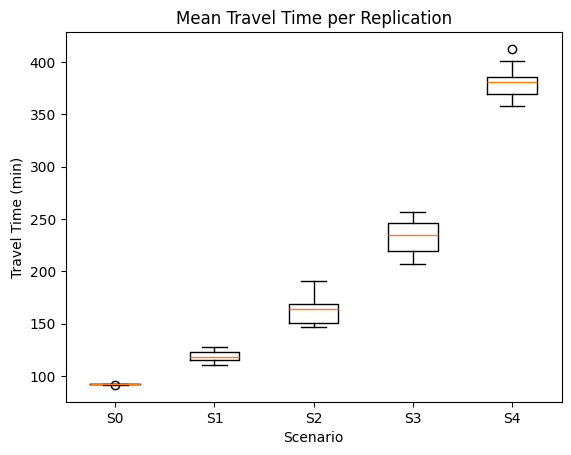

In [4]:
data = []
labels = []

for scenario, df in results.items():
    rep_means = df.groupby("replication")["travel_time_min"].mean()
    data.append(rep_means)
    labels.append(scenario)

plt.boxplot(data, tick_labels=labels)
plt.title("Mean Travel Time per Replication")
plt.ylabel("Travel Time (min)")
plt.xlabel("Scenario")
plt.show()

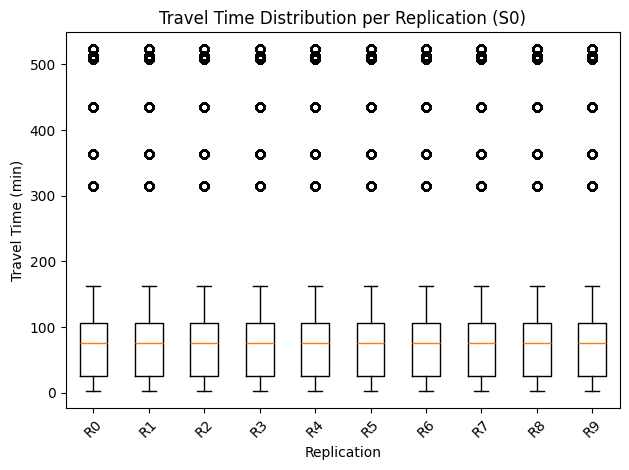

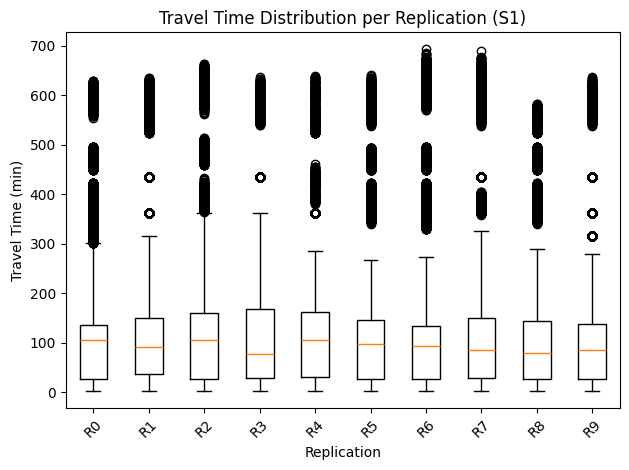

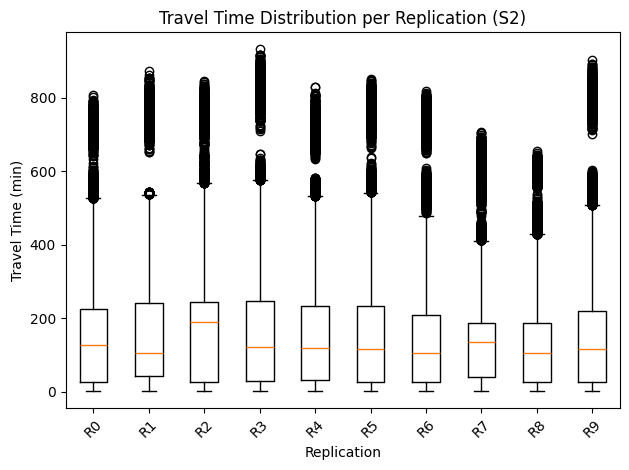

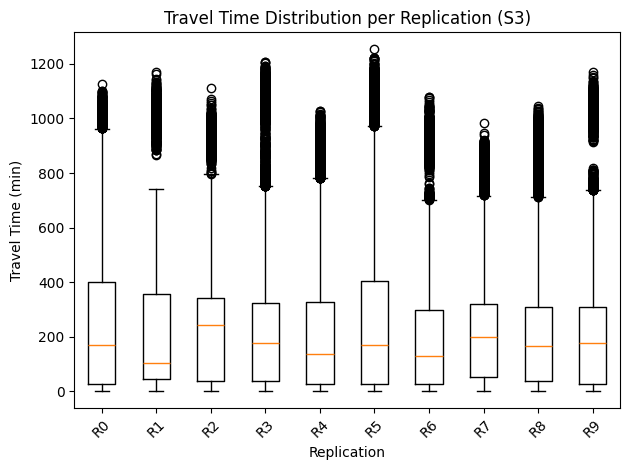

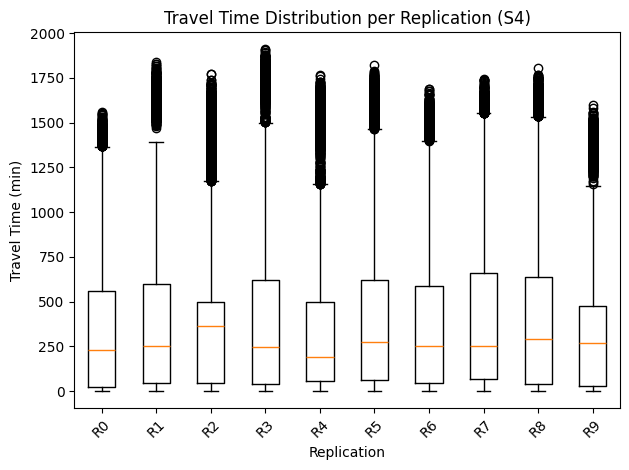

In [5]:
for scenario, df in results.items():
    plt.figure()

    data = []
    labels = []

    for rep in sorted(df["replication"].unique()):
        rep_data = df[df["replication"] == rep]["travel_time_min"]
        data.append(rep_data)
        labels.append(f"R{rep}")

    plt.boxplot(data, tick_labels=labels)
    plt.title(f"Travel Time Distribution per Replication ({scenario})")
    plt.xlabel("Replication")
    plt.ylabel("Travel Time (min)")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

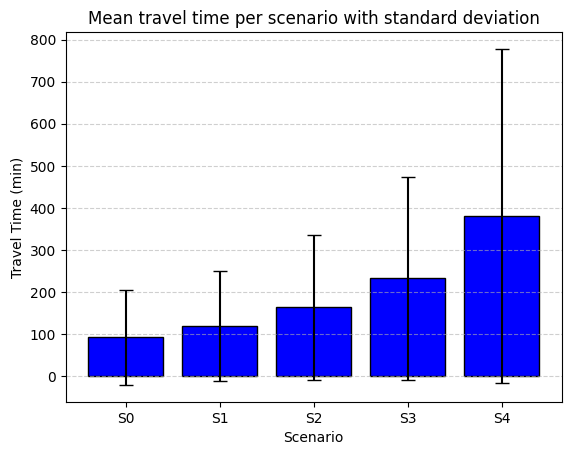

In [6]:
means = []
stds = []
labels = []

for scenario, df in results.items():
    means.append(df["travel_time_min"].mean())
    stds.append(df["travel_time_min"].std())
    labels.append(scenario)

plt.figure()
plt.bar(labels, means, yerr=stds,capsize=5,color="blue",edgecolor="black")
plt.title("Mean travel time per scenario with standard deviation")
plt.xlabel("Scenario")
plt.ylabel("Travel Time (min)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

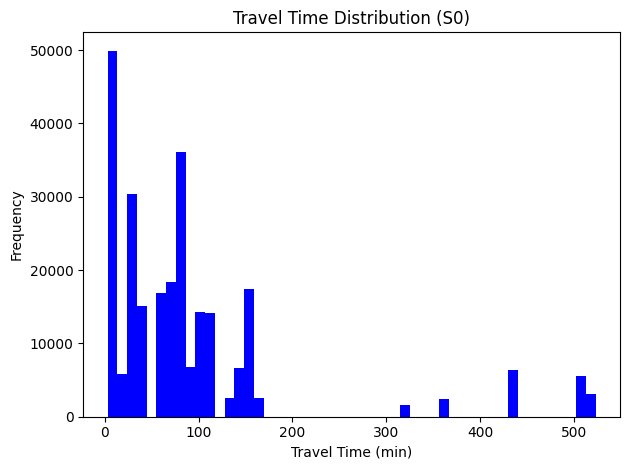

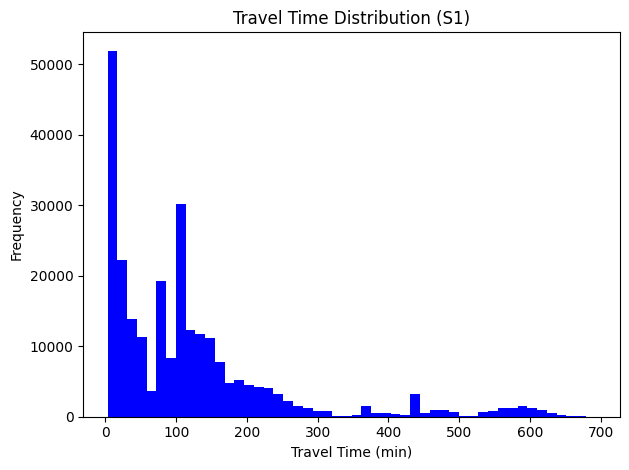

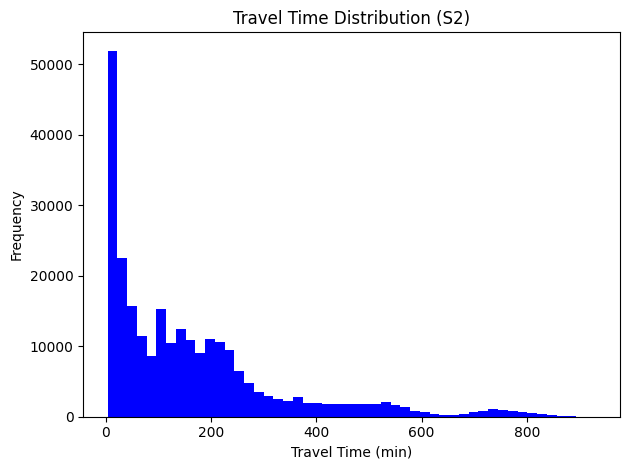

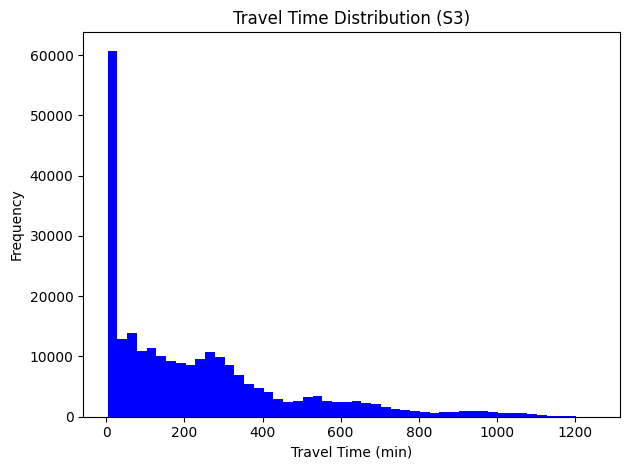

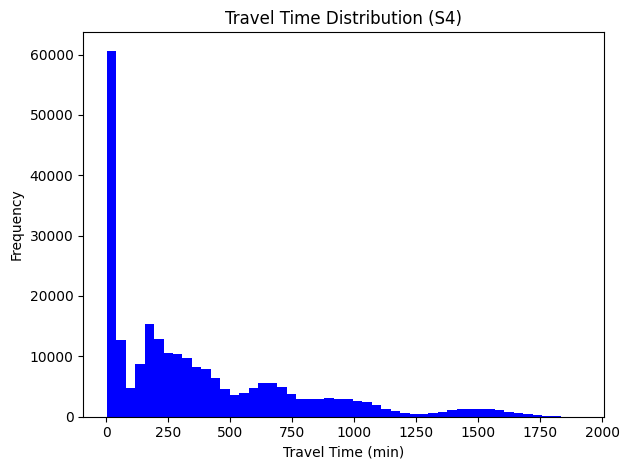

In [7]:
for scenario, df in results.items():
    plt.figure()

    plt.hist(df["travel_time_min"], bins=50, color="blue")
    plt.title(f"Travel Time Distribution ({scenario})")
    plt.xlabel("Travel Time (min)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

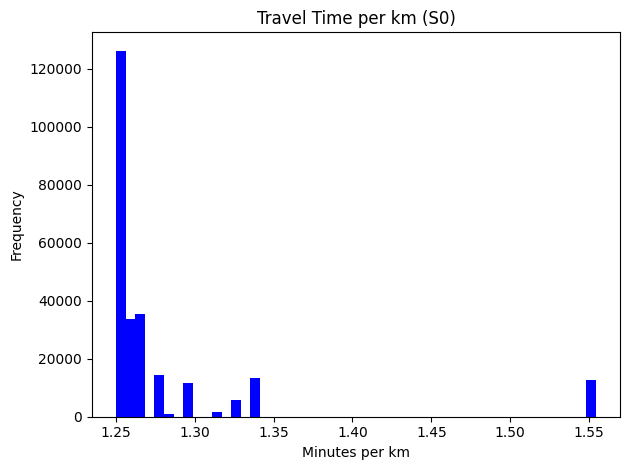

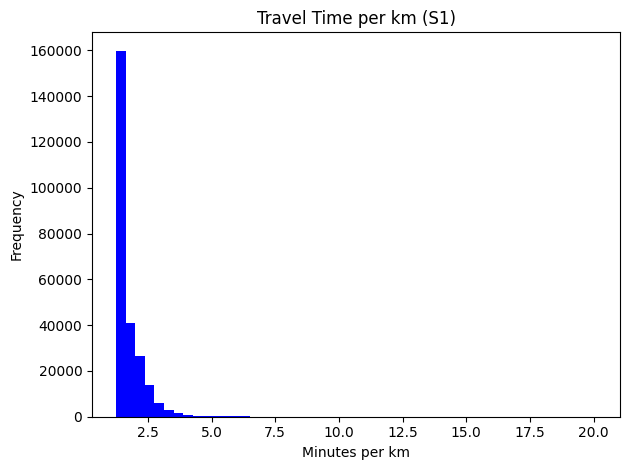

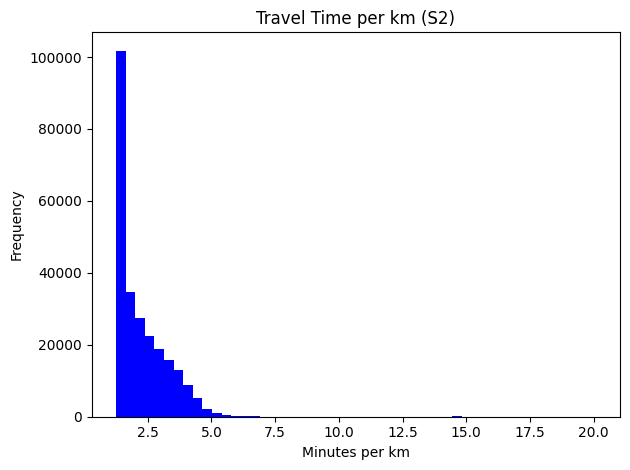

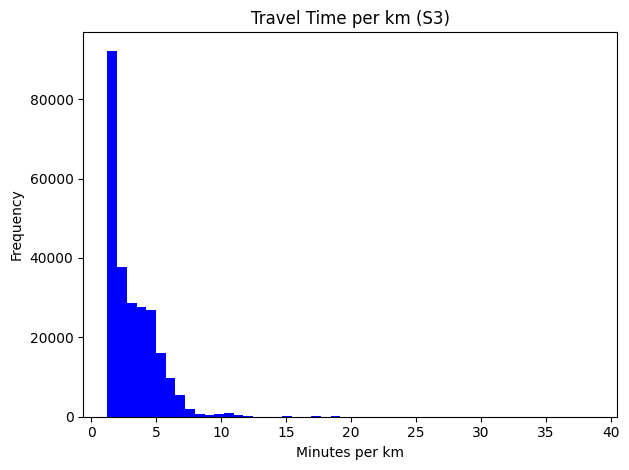

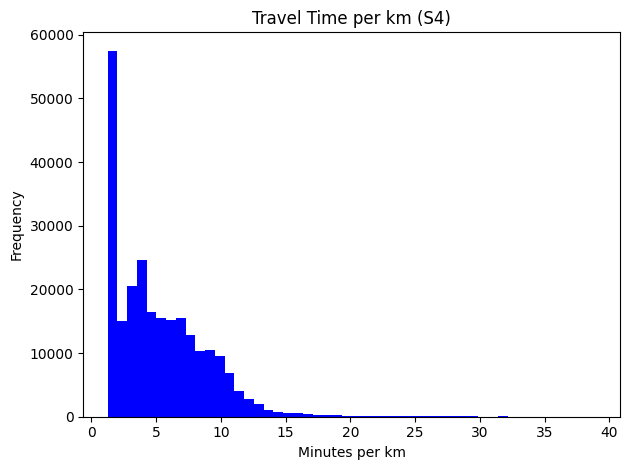

In [8]:
for scenario, df in results.items():
    plt.figure()

    df = df.copy()
    df["time_per_km"] = df["travel_time_min"] / (df["travel_distance_m"] / 1000)

    plt.hist(df["time_per_km"], bins=50, color="blue")
    plt.title(f"Travel Time per km ({scenario})")
    plt.xlabel("Minutes per km")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

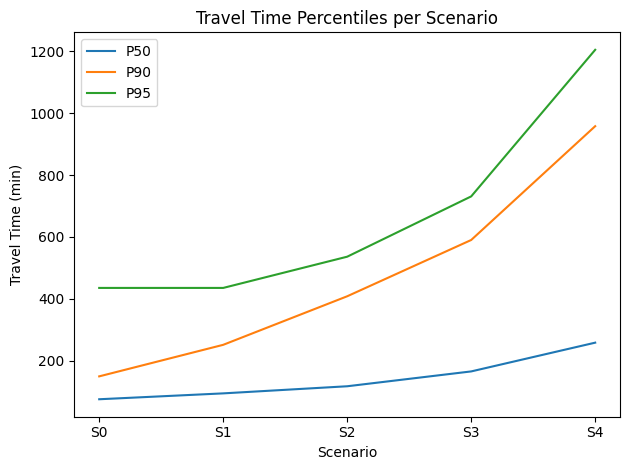

In [9]:
percentiles = []

for scenario, df in results.items():
    percentiles.append({
        "scenario": scenario,
        "p50": df["travel_time_min"].quantile(0.5),
        "p90": df["travel_time_min"].quantile(0.9),
        "p95": df["travel_time_min"].quantile(0.95),
    })

df_percentiles = pd.DataFrame(percentiles)

# Plot
plt.figure()

plt.plot(df_percentiles["scenario"], df_percentiles["p50"], label="P50")
plt.plot(df_percentiles["scenario"], df_percentiles["p90"], label="P90")
plt.plot(df_percentiles["scenario"], df_percentiles["p95"], label="P95")

plt.title("Travel Time Percentiles per Scenario")
plt.xlabel("Scenario")
plt.ylabel("Travel Time (min)")
plt.legend()

plt.tight_layout()
plt.show()

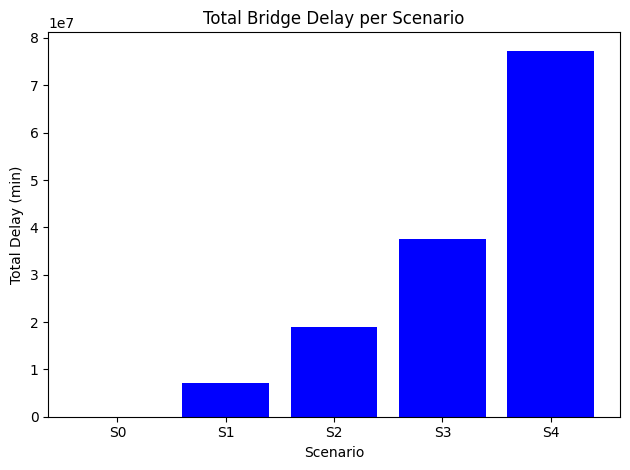

In [11]:
total_delays = []
labels = []

for scenario, df in bridges.items():
    total_delays.append(df["total_delay_min"].sum())
    labels.append(scenario)

plt.figure()
plt.bar(labels, total_delays, color='blue')
plt.title("Total Bridge Delay per Scenario")
plt.xlabel("Scenario")
plt.ylabel("Total Delay (min)")

plt.tight_layout()
plt.show()

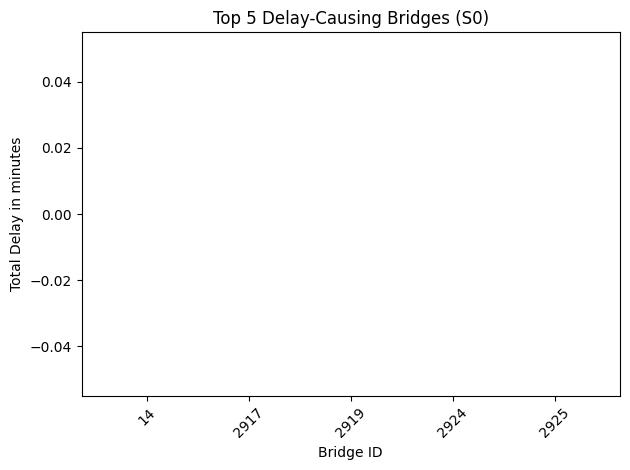

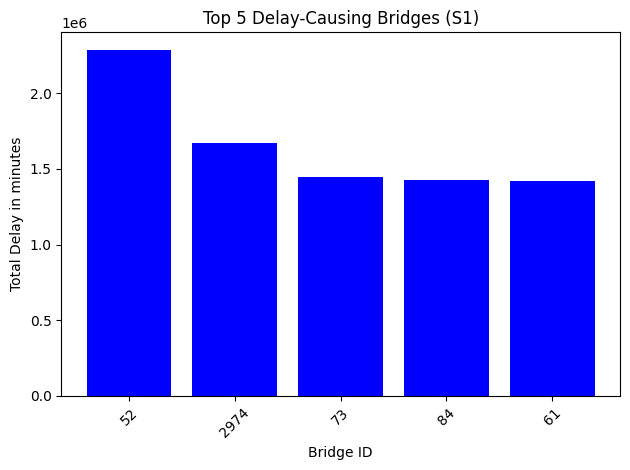

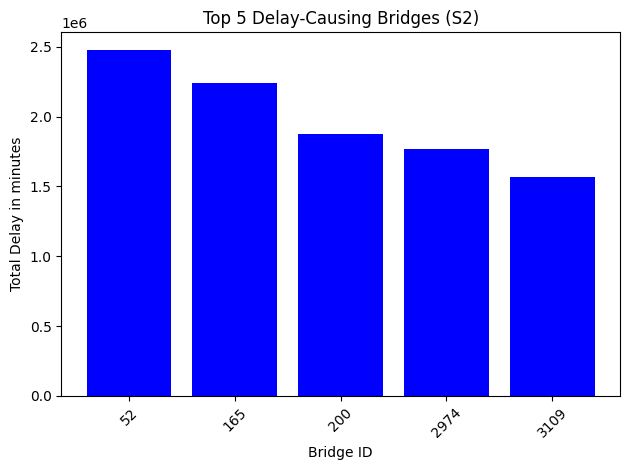

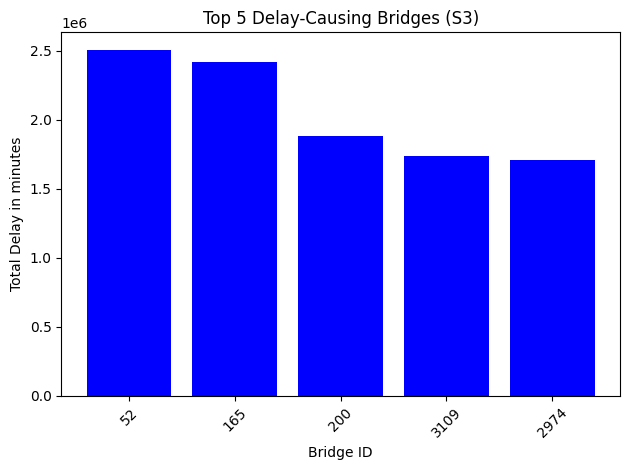

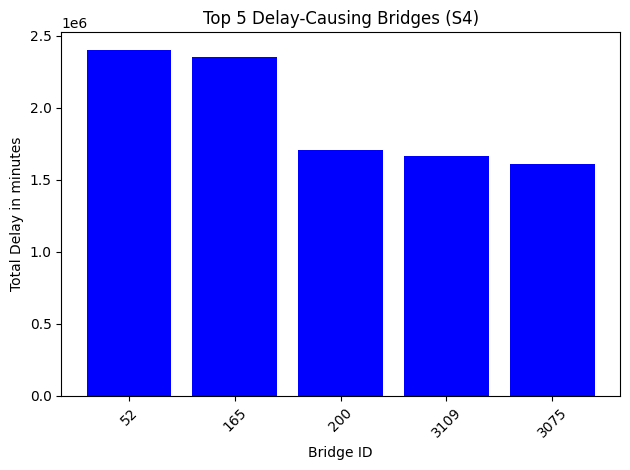

In [55]:
for scenario, df in bridges.items():
    plt.figure()

    top_bridges = (
        df.groupby("bridge_id")["total_delay_min"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    plt.bar(top_bridges.index.astype(str), top_bridges.values, color='blue')

    plt.title(f"Top 5 Delay-Causing Bridges ({scenario})")
    plt.xlabel("Bridge ID")
    plt.ylabel("Total Delay in minutes")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

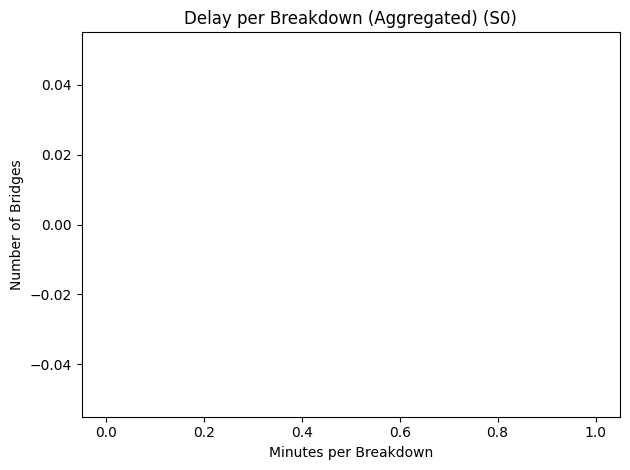

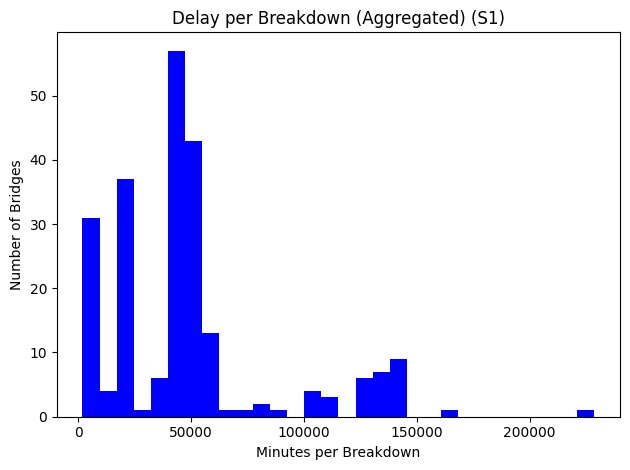

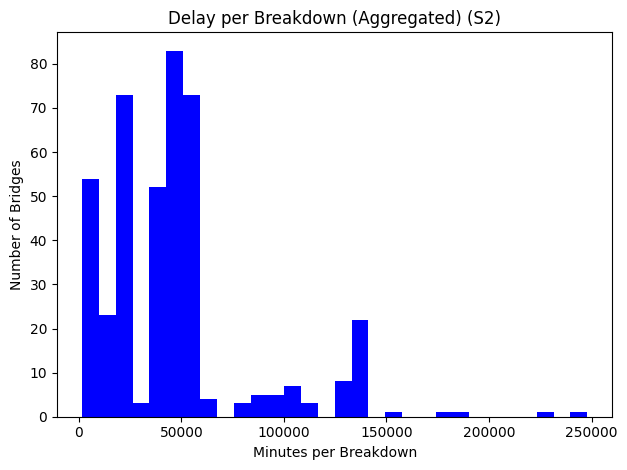

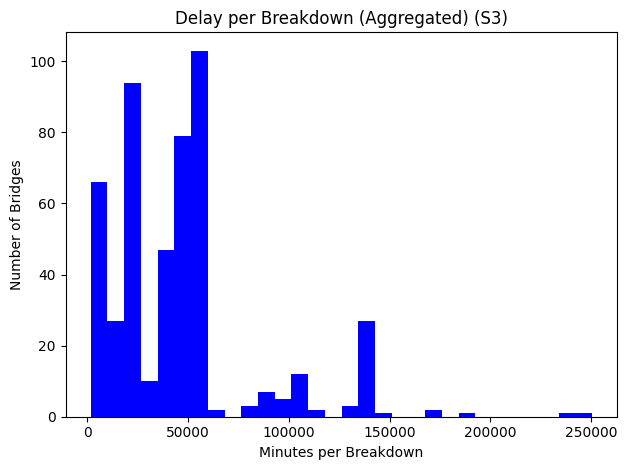

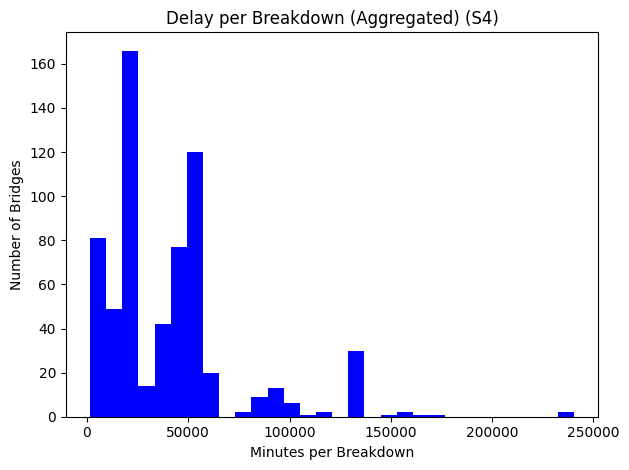

In [57]:
for scenario, df in bridges.items():
    plt.figure()

    # Aggregate across replications
    df_agg = (
        df.groupby("bridge_id")
        .agg({
            "total_delay_min": "sum",
            "breakdown_count": "sum"
        })
        .reset_index()
    )

    # Filter out bridges with no breakdowns
    df_agg = df_agg[df_agg["breakdown_count"] > 0].copy()

    # Compute delay per breakdown
    df_agg["delay_per_breakdown"] = (
        df_agg["total_delay_min"] / df_agg["breakdown_count"]
    )

    # Plot
    plt.hist(df_agg["delay_per_breakdown"], bins=30, color='blue')

    plt.title(f"Delay per Breakdown (Aggregated) ({scenario})")
    plt.xlabel("Minutes per Breakdown")
    plt.ylabel("Number of Bridges")

    plt.tight_layout()
    plt.show()

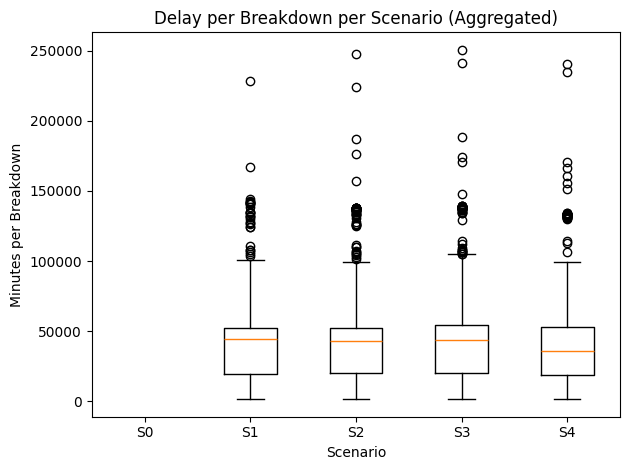

In [59]:
data = []
labels = []

for scenario, df in bridges.items():
    df_agg = (
        df.groupby("bridge_id")
        .agg({
            "total_delay_min": "sum",
            "breakdown_count": "sum"
        })
        .reset_index()
    )

    df_agg = df_agg[df_agg["breakdown_count"] > 0].copy()

    df_agg["delay_per_breakdown"] = (
        df_agg["total_delay_min"] / df_agg["breakdown_count"]
    )

    data.append(df_agg["delay_per_breakdown"])
    labels.append(scenario)

plt.figure()
plt.boxplot(data, tick_labels=labels)

plt.title("Delay per Breakdown per Scenario (Aggregated)")
plt.xlabel("Scenario")
plt.ylabel("Minutes per Breakdown")

plt.tight_layout()
plt.show()